In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
#read the data
df1 = pd.read_csv('AirPassenger.csv')

In [ ]:
#Check data types
df1.dtypes

In [2]:
#We are providing inputs to tell pandas that we are trying to work time series
df1 = pd.read_csv('AirPassenger.csv',parse_dates=['Year-Months'])

In [6]:
df1.dtypes

Year-Months    datetime64[ns]
Passenger               int64
dtype: object

In [12]:
df1.head()

,Passenger
Year-Months,
2023-01-01,116
2023-01-02,129
2023-01-03,125
2023-01-04,121
2023-01-05,118


In [9]:
#It is recommended that we make our time series reference as the index
df1 = pd.read_csv('AirPassenger.csv',parse_dates=['Year-Months'],index_col='Year-Months')

In [10]:
df1.head()

,Passenger
Year-Months,
2023-01-01,116
2023-01-02,129
2023-01-03,125
2023-01-04,121
2023-01-05,118


In [13]:
#we can conveniently do sslicing i.e. obtain data for a specific time period.
df1['2023-01-01':'2023-06-01']

,Passenger
Year-Months,
2023-01-01,116
2023-01-02,129
2023-01-03,125
2023-01-04,121
2023-01-05,118
...,...
2023-05-28,123
2023-05-29,126
2023-05-30,125


In [14]:
#we can check values corresponding specific time period.
df1.loc['2023-05-01']

Passenger    133
Name: 2023-05-01 00:00:00, dtype: int64

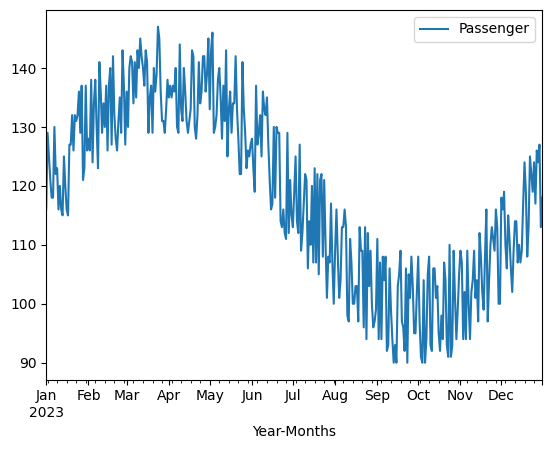

In [15]:
#plot the time series
df1.plot()
plt.show()

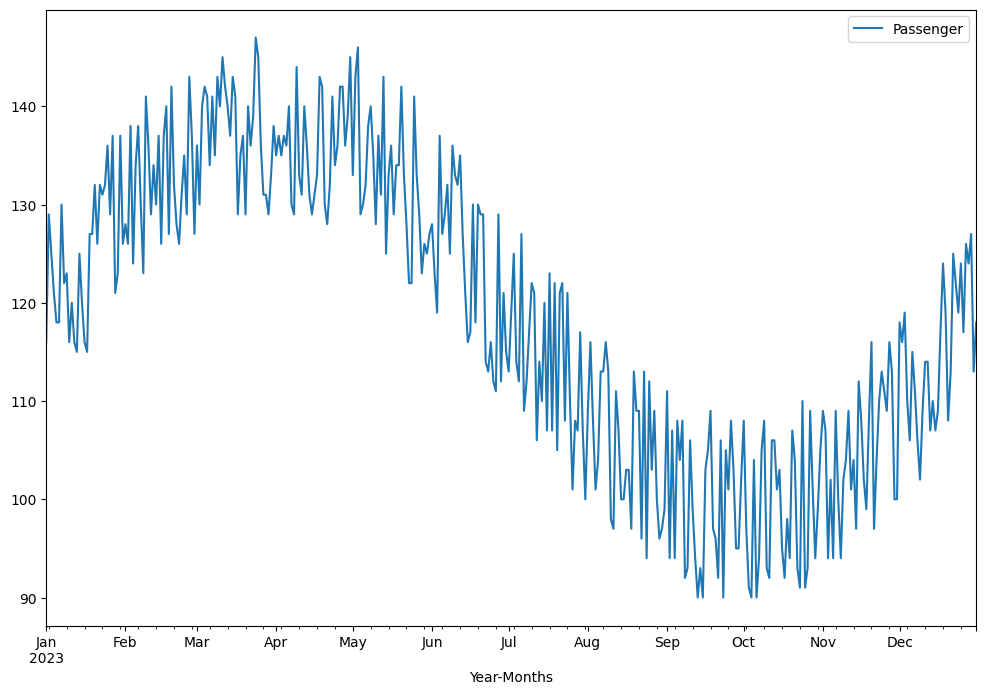

In [17]:
#Increase the figure size
from pylab import rcParams
rcParams['figure.figsize']=12,8
df1.plot()
plt.show()

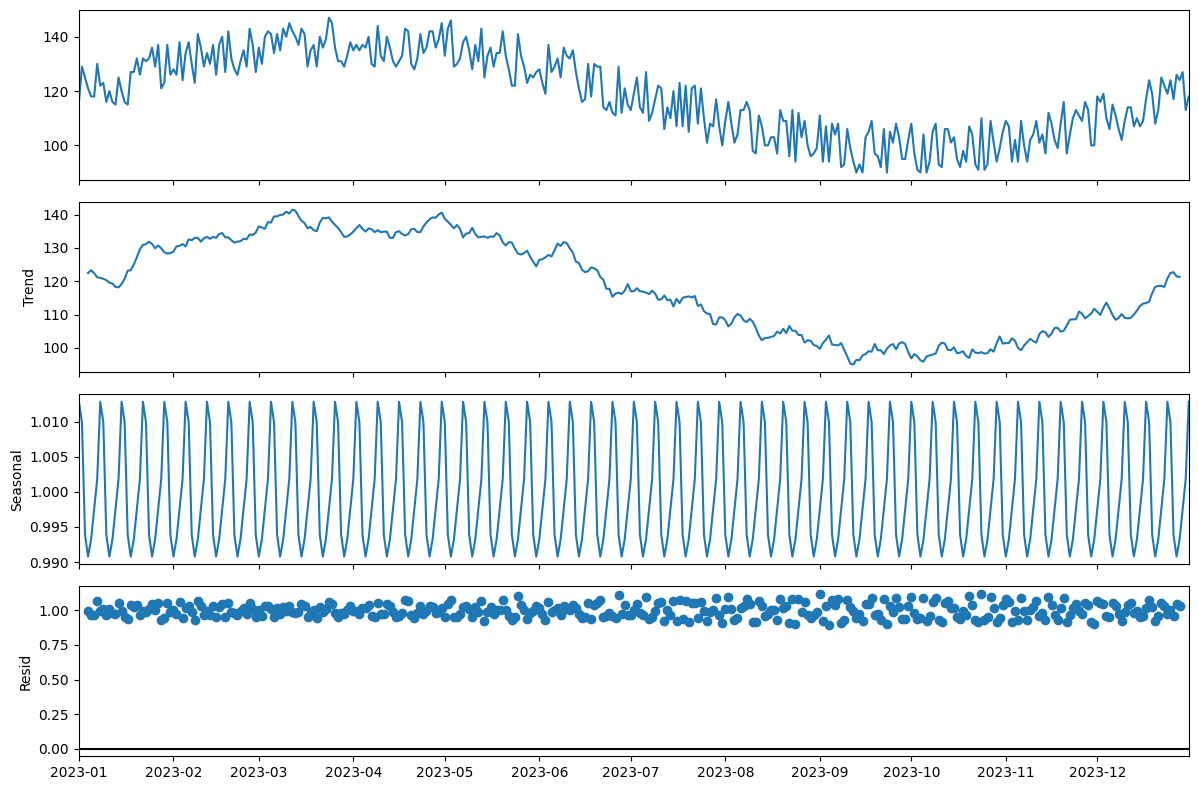

In [18]:
#Decompose the time series multiplicatively
df1_mul_decompose = seasonal_decompose(df1,model='multiplicative')
df1_mul_decompose.plot()
plt.show()

In [19]:
#Let's try to do log transformation
df1_log=df1.copy()

In [20]:
df1_log['Passenger']=np.log(df1)

In [21]:
df1_log.Passenger

Year-Months
2023-01-01    4.753590
2023-01-02    4.859812
2023-01-03    4.828314
2023-01-04    4.795791
2023-01-05    4.770685
                ...   
2023-12-27    4.836282
2023-12-28    4.820282
2023-12-29    4.844187
2023-12-30    4.727388
2023-12-31    4.770685
Name: Passenger, Length: 365, dtype: float64

In [ ]:
#Compare with the original  series
plt.subplot(2,1,1)
plt.title('Original Time Series')
plt.plot(df1)

plt.title('Log Transf Time Series')
plt.plot(df1)